In [ ]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.sandwich_covariance import cov_cluster
from scipy.stats import ttest_rel, zscore
from config import *

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,
                     'axes.spines.right': False, 'axes.spines.top': False})

OUT_DIR = REPO_ROOT / 'results' / 'figs' / 'paper'
OUT_DIR.mkdir(parents=True, exist_ok=True)

beh = pd.read_csv(DATA_DIR / 'behavior.csv')
vigor = pd.read_csv(DATA_DIR / 'trial_vigor.csv')
feelings = pd.read_csv(DATA_DIR / 'feelings.csv')
beh = beh[~beh['subj'].isin(EXCLUDE)]
vigor = vigor[~vigor['subj'].isin(EXCLUDE)]
feelings = feelings[~feelings['subj'].isin(EXCLUDE)]

# Z-score predictors for regressions
beh['threat_z'] = zscore(beh['threat'])
beh['dist_z'] = zscore(beh['distance_H'])
feelings['threat_z'] = zscore(feelings['threat'])
feelings['dist_z'] = zscore(feelings['distance'].astype(float))

# Prepare vigor for H1c
vigor['T_round'] = vigor['T_round'].round(1)
vigor['is_heavy'] = vigor['cookie']
vigor['threat_z'] = zscore(vigor['T_round'])
vigor_valid = vigor[vigor['norm_rate'].notna()].copy()

beh['T_round'] = beh['threat'].round(1)

print(f'Trials: {len(beh)}, Vigor: {len(vigor_valid)}, Feelings: {len(feelings)}')

## H1a — Choice decreases with threat and distance

**Model:** `choice ~ threat_z + dist_z + threat_z:dist_z` (cluster-robust SE by subject)  
**Test:** β(threat) < 0 AND β(distance) < 0, both p < 0.01

In [2]:
# ── H1a: Logistic model — choice ~ threat + distance ──
model_h1a = smf.logit(
    "choice ~ threat_z + dist_z + threat_z:dist_z",
    data=beh
).fit(disp=False, cov_type='cluster', cov_kwds={'groups': beh['subj']})

print("H1a — Logistic regression (cluster-robust SE by subject)")
print("=" * 65)
print(model_h1a.summary2().tables[1][['Coef.', 'Std.Err.', 'z', 'P>|z|']].to_string())
print()

b_threat = model_h1a.params['threat_z']
b_dist = model_h1a.params['dist_z']
p_threat = model_h1a.pvalues['threat_z']
p_dist = model_h1a.pvalues['dist_z']
print(f"Threat:   β = {b_threat:.4f}, p = {p_threat:.2e}  {'PASS' if b_threat < 0 and p_threat < 0.01 else 'FAIL'}")
print(f"Distance: β = {b_dist:.4f}, p = {p_dist:.2e}  {'PASS' if b_dist < 0 and p_dist < 0.01 else 'FAIL'}")

H1a — Logistic regression (cluster-robust SE by subject)
                    Coef.  Std.Err.          z          P>|z|
Intercept       -0.430764  0.066911  -6.437859   1.211706e-10
threat_z        -1.015392  0.045573 -22.280586  5.700668e-110
dist_z          -0.746659  0.031515 -23.692446  4.313866e-124
threat_z:dist_z -0.195329  0.024361  -8.017991   1.074888e-15

Threat:   β = -1.0154, p = 5.70e-110  PASS
Distance: β = -0.7467, p = 4.31e-124  PASS


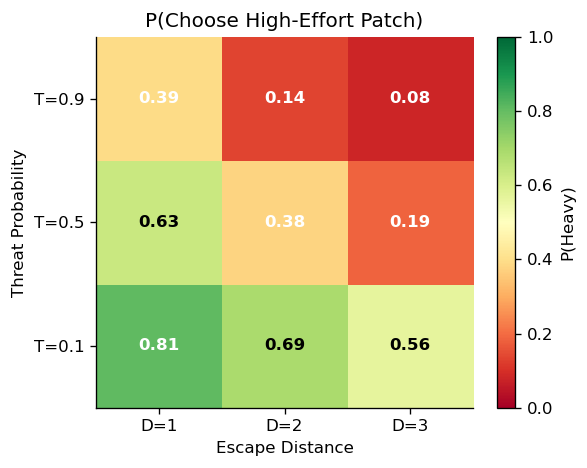

In [3]:
# ── H1a figure: 3×3 Choice Surface ──
choice_surface = beh.groupby(['T_round', 'distance_H'])['choice'].mean().unstack()

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(choice_surface.values, cmap='RdYlGn', vmin=0, vmax=1,
               origin='lower', aspect='auto')
ax.set_xticks(range(3)); ax.set_xticklabels(['D=1', 'D=2', 'D=3'])
ax.set_yticks(range(3)); ax.set_yticklabels(['T=0.1', 'T=0.5', 'T=0.9'])
ax.set_xlabel('Escape Distance'); ax.set_ylabel('Threat Probability')
ax.set_title('P(Choose High-Effort Patch)')
for i in range(3):
    for j in range(3):
        val = choice_surface.values[i, j]
        color = 'white' if val < 0.4 or val > 0.8 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                color=color, fontweight='bold')
plt.colorbar(im, ax=ax, label='P(Heavy)')
plt.tight_layout()
plt.savefig(OUT_DIR / "H1a_choice_surface.png", dpi=150, bbox_inches='tight')
plt.show()

## H1b — Anxiety increases and confidence decreases with threat

**Model:** `response ~ threat_z + (1 + threat_z | subj)` separately for anxiety and confidence  
**Test:** β > 0 for anxiety, β < 0 for confidence, both |t| > 3.0

In [4]:
# ── H1b: Affect ~ threat ──
anx = feelings[feelings['questionLabel'] == 'anxiety'].copy()
con = feelings[feelings['questionLabel'] == 'confidence'].copy()
anx['T_z'] = zscore(anx['threat'].astype(float))
con['T_z'] = zscore(con['threat'].astype(float))

print("H1b — Affect models")
print("=" * 55)

for label, df in [('Anxiety', anx), ('Confidence', con)]:
    try:
        m = smf.mixedlm(
            "response ~ T_z", data=df, groups=df['subj'],
            re_formula="~T_z"
        ).fit(reml=False)
    except Exception:
        m = smf.mixedlm(
            "response ~ T_z", data=df, groups=df['subj']
        ).fit(reml=False)

    b = m.fe_params['T_z']
    z = m.tvalues['T_z']
    p = m.pvalues['T_z']
    print(f"  {label:12s}: β = {b:.4f}, z = {z:.3f}, p = {p:.2e}")
    if label == 'Anxiety':
        passed = b > 0 and abs(z) > 3.0
    else:
        passed = b < 0 and abs(z) > 3.0
    print(f"               {'PASS' if passed else 'FAIL'} (expect {'positive' if label == 'Anxiety' else 'negative'} β, |t| > 3)")
    print()

H1b — Affect models


  Anxiety     : β = 0.5798, z = 14.665, p = 1.08e-48
               PASS (expect positive β, |t| > 3)



  Confidence  : β = -0.5824, z = -13.717, p = 8.00e-43
               PASS (expect negative β, |t| > 3)



## H1c — Vigor increases with threat

Normalized press rate (median(1/IPI) / calibrationMax) increases with threat probability. The effect is small in absolute scale but robust.

**Test:** LMM: `median_rate ~ threat_z + is_heavy + (1 | subj)`, controlling for cookie type. β(threat) > 0, p < 0.01.

In [ ]:
# ── H1c: Vigor ~ threat (LMM, controlling for cookie type) ──

# Mean vigor by threat level
print("Normalized press rate by threat level:")
means = vigor_valid.groupby('T_round')['norm_rate'].agg(['mean', 'sem'])
for t, row in means.iterrows():
    print(f"  T={t}: {row['mean']:.3f} (SE={row['sem']:.4f})")
print()

# LMM controlling for cookie type
model_h1c = smf.mixedlm(
    "norm_rate ~ threat_z + is_heavy",
    data=vigor_valid,
    groups=vigor_valid['subj']
).fit(reml=False)

b = model_h1c.fe_params['threat_z']
z = model_h1c.tvalues['threat_z']
p = model_h1c.pvalues['threat_z']

print("H1c — LMM: vigor ~ threat (controlling for cookie type)")
print("=" * 55)
print(f"  threat_z: β = {b:.4f}, z = {z:.3f}, p = {p:.2e}")
print(f"  is_heavy: β = {model_h1c.fe_params['is_heavy']:.4f}")
print()
print(f"  Verdict: {'PASS' if b > 0 and p < 0.01 else 'FAIL'} (expect positive β, p < 0.01)")

In [ ]:
# ── H1c figure: Vigor by threat level ──
fig, ax = plt.subplots(figsize=(5, 4))
means = vigor_valid.groupby('T_round')['norm_rate'].agg(['mean', 'sem'])
ax.bar(means.index, means['mean'], width=0.25,
       color=['forestgreen', 'gold', 'firebrick'], edgecolor='white',
       yerr=means['sem'] * 1.96, capsize=3)
ax.set_xlabel('Threat Probability')
ax.set_ylabel('Normalized Press Rate')
ax.set_title('H1c: Vigor Increases with Threat')
ax.set_xticks([0.1, 0.5, 0.9])
for t, row in means.iterrows():
    ax.text(t, row['mean'] + row['sem'] * 2.2, f"{row['mean']:.3f}",
            ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / "H1c_vigor_by_threat.png", dpi=150, bbox_inches='tight')
plt.show()